In [1]:
%pip install lightgbm

import pandas as pd
import numpy as np
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, r2_score

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Load Dataset
df = pd.read_csv(r"D:\Data Science\Projects\BioMass\Biomass_History.csv")
df.head()

,Index,Latitude,Longitude,2010,2011,2012,2013,2014,2015,2016,2017
0,0,24.66818,71.33144,8.475744,8.868568,9.202181,6.023070,10.788374,6.647325,7.387925,5.180296
1,1,24.66818,71.41106,24.029778,28.551348,25.866415,21.634459,34.419411,27.361908,40.431847,42.126945
2,2,24.66818,71.49069,44.831635,66.111168,56.982258,53.003735,70.917908,42.517117,59.181629,73.203232
3,3,24.66818,71.57031,59.974419,80.821304,78.956543,63.160561,93.513924,70.203171,74.536720,101.067352
4,4,24.66818,71.64994,14.653370,19.327524,21.928144,17.899586,19.534035,19.165791,16.531315,26.086885


In [3]:
# Check missing values
print("Missing values before handling:\n", df.isnull().sum())

# Forward fill (propagate last valid observation)
df.fillna(method='ffill', inplace=True)

# Optional: backward fill for any remaining NaNs at the top
df.fillna(method='bfill', inplace=True)

print("Missing values after handling:\n", df.isnull().sum())

Missing values before handling:
 Index        0
Latitude     0
Longitude    0
2010         0
2011         0
2012         0
2013         0
2014         0
2015         0
2016         0
2017         0
dtype: int64
Missing values after handling:
 Index        0
Latitude     0
Longitude    0
2010         0
2011         0
2012         0
2013         0
2014         0
2015         0
2016         0
2017         0
dtype: int64


In [4]:
# Sort by the column named "Index"
df.sort_values(by="Index", ascending=True, inplace=True)

print(df.head())

   Index  Latitude  Longitude       2010       2011       2012       2013  \
0      0  24.66818   71.33144   8.475744   8.868568   9.202181   6.023070   
1      1  24.66818   71.41106  24.029778  28.551348  25.866415  21.634459   
2      2  24.66818   71.49069  44.831635  66.111168  56.982258  53.003735   
3      3  24.66818   71.57031  59.974419  80.821304  78.956543  63.160561   
4      4  24.66818   71.64994  14.653370  19.327524  21.928144  17.899586   

        2014       2015       2016        2017  
0  10.788374   6.647325   7.387925    5.180296  
1  34.419411  27.361908  40.431847   42.126945  
2  70.917908  42.517117  59.181629   73.203232  
3  93.513924  70.203171  74.536720  101.067352  
4  19.534035  19.165791  16.531315   26.086885  


In [5]:
# Reshape the DataFrame from wide to long format
df_long = pd.melt(
    df,
    id_vars=["Index", "Latitude", "Longitude"],
    var_name="Year",
    value_name="Biomass"
)

df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
df_long.dropna(subset=["Year"], inplace=True)
df_long["Year"] = df_long["Year"].astype(int)

df_long.sort_values(by=["Index", "Year"], inplace=True)
df_long.reset_index(drop=True, inplace=True)

df_long.head()

,Index,Latitude,Longitude,Year,Biomass
0,0,24.66818,71.33144,2010,8.475744
1,0,24.66818,71.33144,2011,8.868568
2,0,24.66818,71.33144,2012,9.202181
3,0,24.66818,71.33144,2013,6.023070
4,0,24.66818,71.33144,2014,10.788374


In [6]:
# Ensure proper sorting before creating time-based features
df_long.sort_values(by=["Index", "Year"], inplace=True)

# Group once (cleaner)
grouped = df_long.groupby("Index")["Biomass"]

# Lag features
for lag in [1, 2, 3]:
    df_long[f"Lag_{lag}"] = grouped.shift(lag)

# Rolling mean (3-year window)
df_long["Rolling_Mean_3"] = grouped.transform(lambda x: x.rolling(3).mean())

# Growth rate
df_long["Growth_Rate"] = grouped.pct_change()

# Trend feature
df_long["Year_squared"] = df_long["Year"] ** 2

# Drop initial NaNs created by lag/rolling instead of filling with 0
df_long.dropna(inplace=True)

df_long.head()

,Index,Latitude,Longitude,Year,Biomass,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Growth_Rate,Year_squared
3,0,24.66818,71.33144,2013,6.023070,9.202181,8.868568,8.475744,8.031273,-0.345474,4052169
4,0,24.66818,71.33144,2014,10.788374,6.023070,9.202181,8.868568,8.671208,0.791175,4056196
5,0,24.66818,71.33144,2015,6.647325,10.788374,6.023070,9.202181,7.819589,-0.383844,4060225
6,0,24.66818,71.33144,2016,7.387925,6.647325,10.788374,6.023070,8.274541,0.111413,4064256
7,0,24.66818,71.33144,2017,5.180296,7.387925,6.647325,10.788374,6.405182,-0.298816,4068289


In [7]:
# Ensure proper time order
df_long = df_long.sort_values(["Index", "Year"])

# Train-test split
train = df_long.loc[df_long["Year"] <= 2016]
test  = df_long.loc[df_long["Year"] == 2017]

# Feature columns
features = [
    "Latitude", "Longitude", "Year",
    "Year_squared",
    "Lag_1", "Lag_2", "Lag_3",
    "Rolling_Mean_3",
    "Growth_Rate"
]

# Create X and y
X_train, y_train = train[features], train["Biomass"]
X_test, y_test   = test[features], test["Biomass"]

In [8]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model (simple & strong baseline)
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
pred_2017 = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, pred_2017))
r2 = r2_score(y_test, pred_2017)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1418
[LightGBM] [Info] Number of data points in the train set: 9672, number of used features: 9
[LightGBM] [Info] Start training from score 141.457102
RMSE: 22.4637
R² Score: 0.9800


In [9]:
future_years = range(2018, 2027)
future_predictions = []

# Start from last known year
last_data = df_long[df_long["Year"] == 2017].copy()

for year in future_years:

    temp = last_data.copy()

    # Update year features
    temp["Year"] = year
    temp["Year_squared"] = year ** 2

    # Update lag features
    temp["Lag_1"] = last_data["Biomass"]
    temp["Lag_2"] = last_data["Lag_1"]
    temp["Lag_3"] = last_data["Lag_2"]

    # Rolling mean (cleaner)
    temp["Rolling_Mean_3"] = temp[["Lag_1", "Lag_2", "Lag_3"]].mean(axis=1)

    # Growth rate (safer version)
    temp["Growth_Rate"] = (
        (temp["Lag_1"] - temp["Lag_2"]) / temp["Lag_2"]
    ).replace([np.inf, -np.inf], 0).fillna(0)

    # Predict
    temp["Biomass"] = model.predict(temp[features])

    future_predictions.append(temp)

    # Update for next iteration
    last_data = temp.copy()

# Combine all forecasts
forecast_df = pd.concat(future_predictions, ignore_index=True)

forecast_df.head()

,Index,Latitude,Longitude,Year,Biomass,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Growth_Rate,Year_squared
0,0,24.66818,71.33144,2018,4.602165,5.180296,7.387925,6.647325,6.405182,-0.298816,4072324
1,1,24.66818,71.41106,2018,36.246810,42.126945,40.431847,27.361908,36.640233,0.041925,4072324
2,2,24.66818,71.49069,2018,66.166069,73.203232,59.181629,42.517117,58.300659,0.236925,4072324
3,3,24.66818,71.57031,2018,97.838893,101.067352,74.536720,70.203171,81.935748,0.355940,4072324
4,4,24.66818,71.64994,2018,29.327211,26.086885,16.531315,19.165791,20.594664,0.578028,4072324


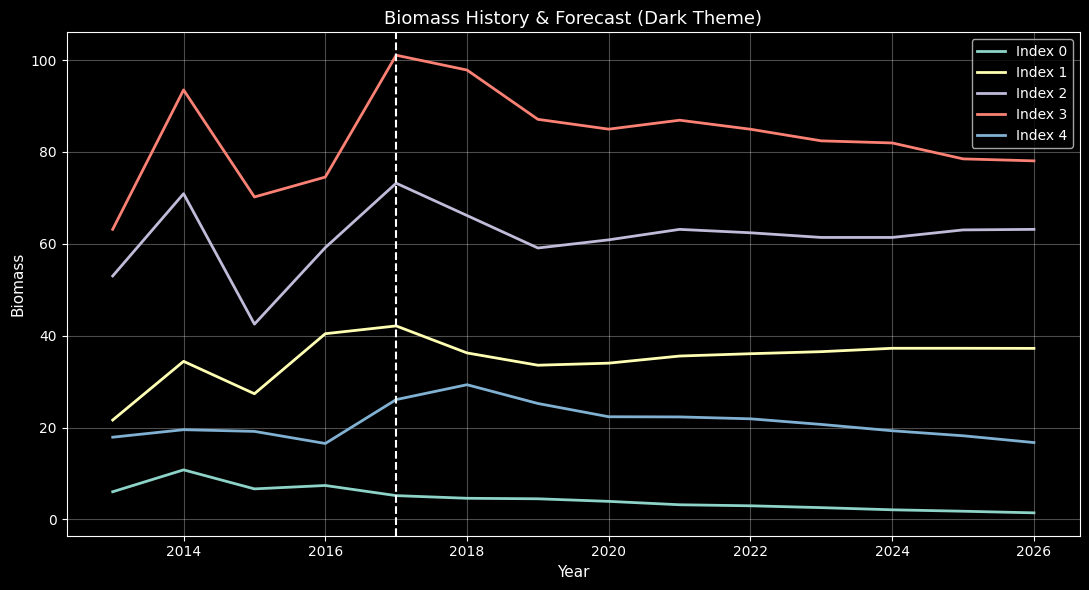

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare Historical Average
history_avg = df_long.groupby(["Year", "Index"])["Biomass"].mean().reset_index()

# 2. Prepare Forecast Average
forecast_avg = forecast_df.groupby(["Year", "Index"])["Biomass"].mean().reset_index()

combined = pd.concat([history_avg, forecast_avg])
plt.style.use("dark_background")

plt.figure(figsize=(11, 6))

for idx in combined["Index"].unique()[:5]:
    temp = combined[combined["Index"] == idx]
    plt.plot(temp["Year"], temp["Biomass"], linewidth=2, label=f"Index {idx}")

plt.axvline(x=2017, linestyle="--", linewidth=1.5)

plt.xlabel("Year", fontsize=11)
plt.ylabel("Biomass", fontsize=11)
plt.title("Biomass History & Forecast (Dark Theme)", fontsize=13)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

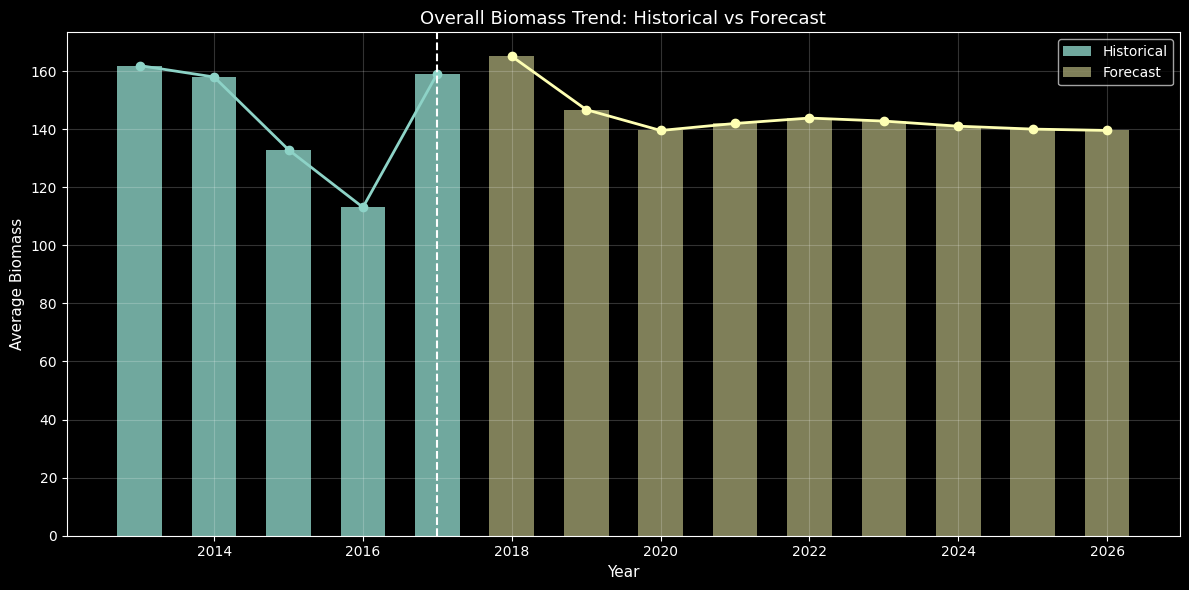

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dark theme
plt.style.use("dark_background")

# Calculate averages
history_avg = df_long.groupby("Year")["Biomass"].mean()
forecast_avg = forecast_df.groupby("Year")["Biomass"].mean()

plt.figure(figsize=(12, 6))

# Bar chart for historical
plt.bar(history_avg.index, history_avg.values,
        width=0.6, label="Historical", alpha=0.8)

# Bar chart for forecast (different transparency)
plt.bar(forecast_avg.index, forecast_avg.values,
        width=0.6, label="Forecast", alpha=0.5)

# Line overlay (smooth trend look)
plt.plot(history_avg.index, history_avg.values,
         marker="o", linewidth=2)

plt.plot(forecast_avg.index, forecast_avg.values,
         marker="o", linewidth=2)

# Forecast split line
plt.axvline(x=2017, linestyle="--", linewidth=1.5)

plt.xlabel("Year", fontsize=11)
plt.ylabel("Average Biomass", fontsize=11)
plt.title("Overall Biomass Trend: Historical vs Forecast", fontsize=13)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
forecast_df[
    ["Index", "Latitude", "Longitude", "Year", "Biomass"]
].to_csv("Biomass_2018_2026_Forecast.csv", index=False)